In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the corrupted dataset
file_path = '/content/Initial_Data.csv'
df = pd.read_csv(file_path)

In [ ]:
df.head()

,user_id,gender,age,stream,sem_1,sem_2,sem_3,sem_4,sem_5,sem_6
0,1,Male,19,Chemical Engineering,NaN,Basics of Electrical and Electronics Engineeri...,"Chemical Process Simulation Using Aspen Plus, ...","Chemical Process Simulation Using Aspen Plus, ...","Chemical Plant Safety Management, Environmenta...","Chemical Plant Safety Management, Environmenta..."
1,2,Male,21,Computer Science and Engineering (CSE),"Introduction to Computer-Aided Design (CAD), E...",NaN,"Foundations of Cybersecurity, Foundations of C...","Foundations of Cybersecurity, Foundations of C...","Mobile App Development with Flutter, DevOps Pr...","Mobile App Development with Flutter, DevOps Pr..."
2,3,Female,23,Mechanical Engineering,"Engineering Mathematics, Environmental Science...","Engineering Mathematics, Environmental Science...","Strength of Materials, Strength of Materials","Strength of Materials, Strength of Materials","Optimization in Mechanical Design, Automobile ...","Optimization in Mechanical Design, Automobile ..."
3,4,Male,24,NaN,"Environmental Science and Sustainability, Intr...","Environmental Science and Sustainability, Intr...","Introduction to Chemical Reaction Engineering,...","Introduction to Chemical Reaction Engineering,...","Nanotechnology in Chemical Engineering, Advanc...","Nanotechnology in Chemical Engineering, Advanc..."
4,5,M,20,Electrical Engineering,"Introduction to Data Science, Introduction to ...","Introduction to Data Science, Introduction to ...","Electrical Machines and Drives, Circuit Theory...","Electrical Machines and Drives, Circuit Theory...","Power Electronics Design, Advanced Power Systems","Power Electronics Design, Advanced Power Systems"


#Exploratory Data Analysis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  2100 non-null   int64 
 1   gender   1887 non-null   object
 2   age      2100 non-null   int64 
 3   stream   1890 non-null   object
 4   sem_1    1889 non-null   object
 5   sem_2    1890 non-null   object
 6   sem_3    2100 non-null   object
 7   sem_4    2100 non-null   object
 8   sem_5    2100 non-null   object
 9   sem_6    2100 non-null   object
dtypes: int64(2), object(8)
memory usage: 164.2+ KB


In [ ]:
df.describe()

,user_id,age
count,2100.000000,2100.000000
mean,1002.513810,23.247619
std,578.359094,9.130133
min,1.000000,19.000000
25%,500.750000,20.000000
50%,1003.500000,22.000000
75%,1504.250000,24.000000
max,2000.000000,100.000000


In [ ]:
df.isnull().sum()

,0
user_id,0
gender,213
age,0
stream,210
sem_1,211
sem_2,210
sem_3,0
sem_4,0
sem_5,0
sem_6,0


In [ ]:
# 1. Handle Missing Values
for col in ['gender', 'stream', 'sem_1', 'sem_2']:
    df[col].fillna('Unknown', inplace=True)

<ipython-input-7-52b2298b23e7>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('Unknown', inplace=True)


In [ ]:
df.isnull().sum()

,0
user_id,0
gender,0
age,0
stream,0
sem_1,0
sem_2,0
sem_3,0
sem_4,0
sem_5,0
sem_6,0


In [ ]:
df.duplicated().sum()

91

In [ ]:
# 2. Remove Duplicate Rows
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

0

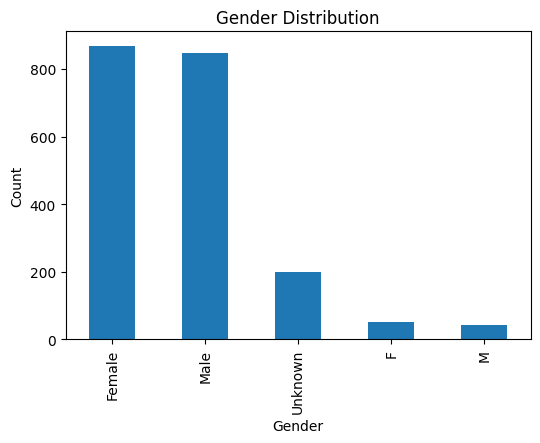

In [ ]:
# Gender distribution
plt.figure(figsize=(6, 4))
df['gender'].value_counts().plot(kind='bar')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

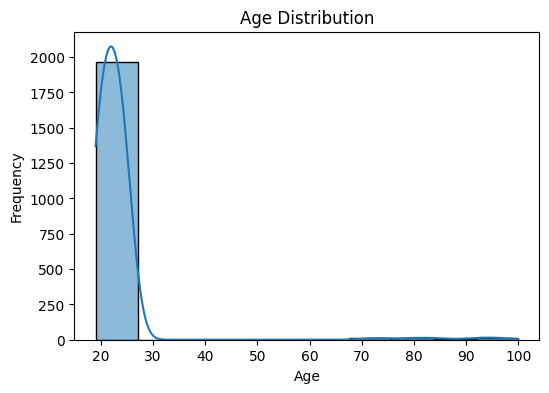

In [ ]:
# Age distribution
plt.figure(figsize=(6, 4))
sns.histplot(df['age'], kde=True, bins=10)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

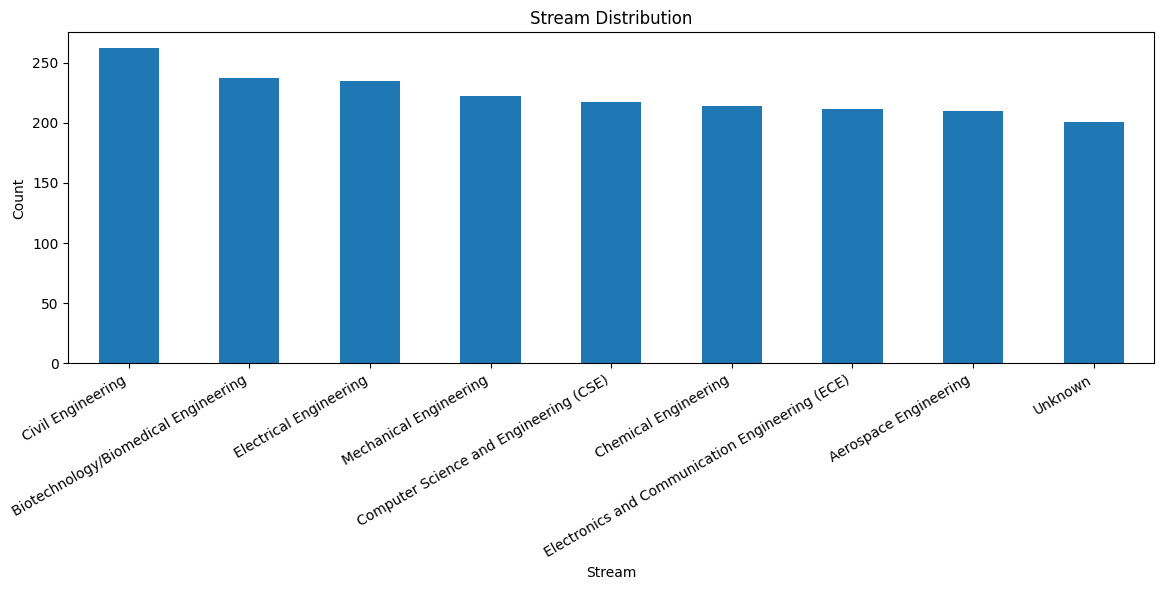

In [ ]:
# Stream distribution with proper alignment
plt.figure(figsize=(12, 6))  # Increase figure size for better alignment
df['stream'].value_counts().plot(kind='bar')
plt.title('Stream Distribution')
plt.xlabel('Stream')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')  # Rotate and align x-tick labels to the right
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()

In [ ]:
# 3. Fix Inconsistent Formats
# Map inconsistent gender values to standard ones
df['gender'] = df['gender'].replace({'M': 'Male', 'F': 'Female', 'O': 'Other'})

In [ ]:
# 4. Handle Outliers in Age
# Remove unrealistic ages (e.g., below 15 or above 60)
df = df[(df['age'] >= 15) & (df['age'] <= 60)]

In [ ]:
# Save the sanitized dataset
file_path_sanitized = 'Sanitized_Synthetic_Student_Course_Data.csv'
df.to_csv(file_path_sanitized, index=False)

print(f"Sanitized dataset saved as '{file_path_sanitized}'.")

Sanitized dataset saved as 'Sanitized_Synthetic_Student_Course_Data.csv'.


#collaborative filtering recommender system

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

In [ ]:
# Load the user data
user_data_path = '/content/Sanitized_Synthetic_Student_Course_Data.csv'
user_data = pd.read_csv(user_data_path)

In [ ]:
# Step 1: Combine courses from Semester 3 & 4 and Semester 5 & 6 into a single list for each user
user_data['all_courses'] = user_data[['sem_3', 'sem_4', 'sem_5', 'sem_6']].apply(
    lambda row: ', '.join(row.dropna().astype(str)), axis=1
)
user_data['all_courses'] = user_data['all_courses'].str.split(', ').apply(lambda courses: list(set(courses)))

# Create a set of all unique courses
all_unique_courses = set(course for courses in user_data['all_courses'] for course in courses)

# Construct the binary user-course matrix
user_course_matrix = pd.DataFrame(0, index=user_data['user_id'], columns=sorted(all_unique_courses))
for idx, courses in zip(user_data['user_id'], user_data['all_courses']):
    user_course_matrix.loc[idx, courses] = 1

In [ ]:
# Step 2: Calculate user-user similarity matrix using cosine similarity
sparse_user_course_matrix = csr_matrix(user_course_matrix.values)
user_similarity_matrix = cosine_similarity(sparse_user_course_matrix)

In [ ]:
# Create a DataFrame for the user-user similarity matrix
user_similarity_df = pd.DataFrame(
    user_similarity_matrix,  # The matrix computed using cosine similarity
    index=user_course_matrix.index,  # Use user IDs as the row index
    columns=user_course_matrix.index  # Use user IDs as the column index
)
# Display the first few rows of the similarity matrix
print(user_similarity_df.head(10))

user_id  1     2     3     4     5     6     7     8     9     10    ...  \
user_id                                                              ...   
1         1.0   0.0   0.0   0.0   0.0  0.00   0.0   0.0  0.00  0.00  ...   
2         0.0   1.0   0.0   0.0   0.0  0.00   0.0   0.0  0.00  0.00  ...   
3         0.0   0.0   1.0   0.0   0.0  0.00   0.0   0.0  0.00  0.00  ...   
4         0.0   0.0   0.0   1.0   0.0  0.00   0.0   0.0  0.00  0.00  ...   
5         0.0   0.0   0.0   0.0   1.0  0.00   0.0   0.0  0.00  0.00  ...   
6         0.0   0.0   0.0   0.0   0.0  1.00   0.0   0.0  0.25  0.00  ...   
7         0.0   0.0   0.0   0.0   0.0  0.00   1.0   0.0  0.00  0.00  ...   
8         0.0   0.0   0.0   0.0   0.0  0.00   0.0   1.0  0.00  0.00  ...   
9         0.0   0.0   0.0   0.0   0.0  0.25   0.0   0.0  1.00  0.25  ...   
10        0.0   0.0   0.0   0.0   0.0  0.00   0.0   0.0  0.25  1.00  ...   

user_id  2000  906   1119  1647  965   30    1569  508       369      1885  
user_id   

In [ ]:
# Step 3: Predict course preferences
predicted_preferences = user_similarity_matrix @ user_course_matrix.values
similarity_sum = user_similarity_matrix.sum(axis=1).reshape(-1, 1)
normalized_predictions = predicted_preferences / similarity_sum

In [ ]:
# Step 4: Take user input and generate recommendations
try:
    user_id = int(input("Enter the User ID for recommendations: "))

    # Ensure the user ID is valid
    if user_id in user_data['user_id'].values:
        # Get predicted preferences for the user
        user_recommendations = pd.Series(normalized_predictions[user_id - 1], index=user_course_matrix.columns)
        user_recommendations = user_recommendations.sort_values(ascending=False)

        # Filter out courses the user has already taken
        already_taken = set(user_data.loc[user_data['user_id'] == user_id, 'all_courses'].values[0])
        new_recommendations = [course for course in user_recommendations.index if course not in already_taken]

        # Display the top 5 recommendations
        print(f"Top 5 Recommendations for User ID {user_id}: \n {new_recommendations[:5]}")
    else:
        print(f"User ID {user_id} not found in the dataset.")
except ValueError:
    print("Invalid User ID. Please enter a valid numeric User ID.")

Enter the User ID for recommendations: 2
Top 5 Recommendations for User ID 2: 
 ['Object-Oriented Programming with Java', 'Blockchain Basics', 'Data Structures and Algorithms', 'Introduction to Cloud Computing', 'Database Management Systems']


In [ ]:
# Create a similarity DataFrame
user_similarity_df = pd.DataFrame(
    user_similarity_matrix,
    index=user_data['user_id'],
    columns=user_data['user_id']
)

# Display the most similar users for each user
most_similar_users = user_similarity_df.apply(
    lambda row: row.nlargest(2).index.tolist()[1], axis=1
)  # Get the second-largest similarity score (ignoring the user themselves)

# Show the most similar user for each user
similarity_pairs = pd.DataFrame({
    "User": user_similarity_df.index,
    "Most Similar User": most_similar_users
})

# Display the similarity pairs directly
print(similarity_pairs.head())  # Show the first few rows

         User  Most Similar User
user_id                         
1           1                407
2           2               1633
3           3                576
4           4               1332
5           5                932


#content based filtering recommender system

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# Load the dataset
file_path = '/content/Course_Features.csv'
course_features = pd.read_csv(file_path)

In [ ]:
course_features.head()

,Course Name,Course Description
0,Introduction to Python Programming,"Basics of Python programming, syntax, and appl..."
1,Engineering Mathematics,Mathematical techniques for engineering applic...
2,Basics of Electrical and Electronics Engineering,Fundamentals of electrical and electronic systems
3,Introduction to Data Science,"Foundations of data analysis, statistics, and ..."
4,Engineering Mechanics,Basic principles of forces and motion in engin...


In [ ]:
# Function to preprocess text
import re
def preprocess_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special characters
    text = text.lower()  # Convert to lowercase
    return text

# Preprocess course descriptions
course_features['Processed Description'] = course_features['Course Description'].apply(preprocess_text)

In [ ]:
course_features['Processed Description'].head()

,Processed Description
0,basics of python programming syntax and applic...
1,mathematical techniques for engineering applic...
2,fundamentals of electrical and electronic systems
3,foundations of data analysis statistics and vi...
4,basic principles of forces and motion in engin...


In [ ]:
# Compute the TF-IDF matrix for the course descriptions
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(course_features['Processed Description'])

In [ ]:
# Compute cosine similarity between courses
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [ ]:
# Function to get similar courses
def get_similar_courses(course_name, cosine_sim=cosine_sim, df=course_features):
    # Find the index of the course
    idx = df[df['Course Name'] == course_name].index[0]

    # Get similarity scores for all courses with the selected course
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort courses by similarity scores in descending order
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the top 5 similar courses (excluding itself)
    sim_scores = sim_scores[1:6]

    # Get the course names and their similarity scores
    similar_courses = [(df.iloc[i[0]]['Course Name'], i[1]) for i in sim_scores]

    return similar_courses

In [ ]:
# Test with a course name
example_course = "Introduction to Machine Learning"
similar_courses = get_similar_courses(example_course)

# Print the similar courses
for course, score in similar_courses:
    print(f"Course: {course}, Similarity Score: {score:.2f}")

Course: Artificial Intelligence Foundations, Similarity Score: 0.34
Course: Foundations of Cybersecurity, Similarity Score: 0.23
Course: Healthcare Data Analytics, Similarity Score: 0.22
Course: Introduction to Data Science, Similarity Score: 0.17
Course: Bioinformatics Applications in Genomics, Similarity Score: 0.16


#Hybrid recommender system

In [ ]:
# Load the datasets
course_features_path = '/content/Course_Features.csv'
student_course_data_path = '/content/Sanitized_Synthetic_Student_Course_Data.csv'

course_features = pd.read_csv(course_features_path)
student_course_data = pd.read_csv(student_course_data_path)

In [ ]:
# Preprocess text for content-based filtering
def preprocess_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    return text

course_features['Processed Description'] = course_features['Course Description'].apply(preprocess_text)

In [ ]:
# Content-Based Filtering: Compute TF-IDF and cosine similarity
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(course_features['Processed Description'])
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [ ]:
# Collaborative Filtering: User-course matrix and similarity
student_course_data['all_courses'] = student_course_data[['sem_3', 'sem_4', 'sem_5', 'sem_6']].apply(
    lambda row: ', '.join(row.dropna().astype(str)), axis=1
)
student_course_data['all_courses'] = student_course_data['all_courses'].str.split(', ').apply(lambda courses: list(set(courses)))

all_unique_courses = set(course for courses in student_course_data['all_courses'] for course in courses)
user_course_matrix = pd.DataFrame(0, index=student_course_data['user_id'], columns=sorted(all_unique_courses))

for idx, courses in zip(student_course_data['user_id'], student_course_data['all_courses']):
    user_course_matrix.loc[idx, courses] = 1

sparse_user_course_matrix = csr_matrix(user_course_matrix.values)
user_similarity_matrix = cosine_similarity(sparse_user_course_matrix)

In [ ]:
def hybrid_recommendation_with_scores(user_id, top_n=5):
    if user_id not in student_course_data['user_id'].values:
        return f"User ID {user_id} not found."

    # Collaborative Filtering Component
    user_index = student_course_data[student_course_data['user_id'] == user_id].index[0]
    user_sim_scores = user_similarity_matrix[user_index]
    user_course_pref = np.dot(user_sim_scores, user_course_matrix.values)
    user_course_pref /= user_sim_scores.sum() if user_sim_scores.sum() != 0 else 1

    # Content-Based Filtering Component
    user_courses = student_course_data.loc[user_index, 'all_courses']
    course_indices = [course_features[course_features['Course Name'] == course].index[0]
                      for course in user_courses if course in course_features['Course Name'].values]

    if not course_indices:
        return f"No valid courses found for User ID {user_id}."

    content_scores = cosine_sim[course_indices].mean(axis=0)

    # Align Content-Based Scores to User-Course Matrix
    aligned_content_scores = pd.Series(content_scores, index=course_features['Course Name'])
    aligned_content_scores = aligned_content_scores.reindex(user_course_matrix.columns, fill_value=0).values

    # Combine Scores
    hybrid_scores = user_course_pref + aligned_content_scores

    # Get Course Recommendations and Similarity Scores
    recommendations = pd.Series(hybrid_scores, index=user_course_matrix.columns)
    already_taken = set(user_courses)
    recommendations = recommendations[~recommendations.index.isin(already_taken)]
    recommendations = recommendations.sort_values(ascending=False).head(top_n)

    # Return recommendations and similarity scores
    return recommendations.index.tolist(), recommendations.values.tolist()


In [ ]:
try:
    # Prompt the user to enter their user ID
    user_id = int(input("Enter your User ID: "))

    # Get recommendations with similarity scores
    recommended_courses, similarity_scores = hybrid_recommendation_with_scores(user_id, top_n=5)

    # Print recommendations and similarity scores
    print(f"\nTop 5 Recommended Courses for User ID {user_id}:")
    for course, score in zip(recommended_courses, similarity_scores):
        print(f"Course: {course}, Similarity Score: {score:.4f}")

except ValueError:
    print("Invalid input. Please enter a numeric User ID.")
except Exception as e:
    print(f"An error occurred: {e}")


Enter your User ID: 2

Top 5 Recommended Courses for User ID 2:
Course: Cybersecurity and Ethical Hacking, Similarity Score: 0.2809
Course: Introduction to Cloud Computing, Similarity Score: 0.2568
Course: Object-Oriented Programming with Java, Similarity Score: 0.2538
Course: Introduction to Machine Learning, Similarity Score: 0.2419
Course: Database Management Systems, Similarity Score: 0.2337


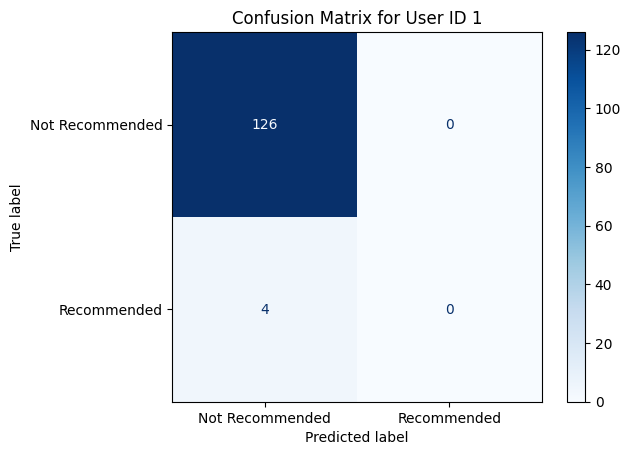

Confusion Matrix:
 [[126   0]
 [  4   0]]


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_recommendations(user_id, top_n=5):
    # Get recommendations
    recommendations = hybrid_recommendation_with_scores(user_id, top_n=top_n)

    # True courses taken by the user
    user_courses = student_course_data.loc[student_course_data['user_id'] == user_id, 'all_courses'].values[0]

    # Create binary arrays for all courses
    all_courses = user_course_matrix.columns
    true_labels = [1 if course in user_courses else 0 for course in all_courses]
    predicted_labels = [1 if course in recommendations else 0 for course in all_courses]

    # Compute confusion matrix
    cm = confusion_matrix(true_labels, predicted_labels)

    # Display confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Recommended", "Recommended"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix for User ID {user_id}")
    plt.show()

    return cm

# Example: Evaluate recommendations for User ID 1
user_id = 1  # Replace with a valid user_id
conf_matrix = evaluate_recommendations(user_id, top_n=5)
print("Confusion Matrix:\n", conf_matrix)